Comenzamos importando pandas para poder obtener los datos de nuestro csv.

In [94]:
# Importaciones necesarias para correr el notebook correctamente
import pandas as pd;
import numpy as np;
import seaborn as sns;
import matplotlib as mpl;
import matplotlib.pyplot as plt;


pd.set_option('display.max_columns', None) #Modificamos el stting default de pandas para poder ver todas las columnas

datos_bancarios = pd.read_csv('../raw_data/bank-additional.csv', index_col = 0)
datos_bancarios.head(2)


,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,999,0,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,999,0,NONEXISTENT,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097


Renombramos la columna de "_id" a "ID" para poder ejecutar el merge de manera directa on "ID".

In [95]:
rename_ID = datos_bancarios["id_"]
datos_bancarios.drop("id_",axis = 1,inplace = True)
datos_bancarios['ID'] = rename_ID

In [96]:
datos_bancarios["ID"].head(3)

0    089b39d8-e4d0-461b-87d4-814d71e0e079
1    e9d37224-cb6f-4942-98d7-46672963d097
2    3f9f49b5-e410-4948-bf6e-f9244f04918b
Name: ID, dtype: object

Importamos los datos de nuestro xlsx.

In [97]:
datos_clientes_2012 = pd.read_excel(
    '../raw_data/customer-details.xlsx',
    sheet_name='2012',    
    index_col=0,          
    header=0,
    engine='openpyxl'
)
print('Clientes 2012')
datos_clientes_2012.head(2)


Clientes 2012


,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097


In [98]:
datos_clientes_2013 = pd.read_excel(
    '../raw_data/customer-details.xlsx',
    sheet_name='2013',    
    index_col=0,          
    header=0,
    engine='openpyxl'
)
print('Clientes 2013')
datos_clientes_2013.head(2)

Clientes 2013


,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be
1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479


In [99]:
datos_clientes_2014 = pd.read_excel(
    '../raw_data/customer-details.xlsx',
    sheet_name='2014',    
    index_col=0,          
    header=0,
    engine='openpyxl'
)
print('Clientes 2014')
datos_clientes_2014.head(2)

Clientes 2014


,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,168812,1,1,2014-06-10,27,4d6c811c-0f24-4a73-b374-2ebd1f80d46e
1,108615,2,1,2014-04-05,24,eef0f24f-cbdb-4c67-b371-09d7bc59695e


Realizamos, ahora sí, el merge para contar con nuestros datos centralizados.

In [100]:
bank_data = datos_bancarios.merge(datos_clientes_2012, how= 'inner', on='ID')
bank_data = datos_bancarios.merge(datos_clientes_2013, how= 'inner', on='ID')
bank_data = datos_bancarios.merge(datos_clientes_2014, how= 'inner', on='ID')
bank_data.set_index('ID')

clientesDuplicados = bank_data['ID'].duplicated().sum()
print(f'Número total de duplicados: {clientesDuplicados} clientes')
bank_data.head(2)


Número total de duplicados: 0 clientes


,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,36.0,admin.,SINGLE,high.school,0.0,1.0,0.0,telephone,777,2,999,0,NONEXISTENT,-1.8,"93,075","-47,1",NaN,"5099,1",no,3-junio-2019,37.506,-118.282,4d6c811c-0f24-4a73-b374-2ebd1f80d46e,168812,1,1,2014-06-10,27
1,39.0,admin.,MARRIED,university.degree,0.0,1.0,0.0,cellular,161,1,999,1,FAILURE,-1.8,"93,075","-47,1","1,405","5099,1",no,10-julio-2017,45.703,-90.123,eef0f24f-cbdb-4c67-b371-09d7bc59695e,108615,2,1,2014-04-05,24


Para realizar el formateo de la columna 'Income' tendremos que obtener la serie, asegurarnos de que el type es correcto (float) y ayudarnos del .map para aplicar el formateo deseado.

En este caso el formateo consta de un separador de miles, dos decimales y con 'f' nos aseguramos de que sea legible como formato float.

In [101]:
bank_data['Income'] = bank_data['Income'].astype(float).round(2)
bank_data.head(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,36.0,admin.,SINGLE,high.school,0.0,1.0,0.0,telephone,777,2,999,0,NONEXISTENT,-1.8,"93,075","-47,1",NaN,"5099,1",no,3-junio-2019,37.506,-118.282,4d6c811c-0f24-4a73-b374-2ebd1f80d46e,168812.0,1,1,2014-06-10,27
1,39.0,admin.,MARRIED,university.degree,0.0,1.0,0.0,cellular,161,1,999,1,FAILURE,-1.8,"93,075","-47,1","1,405","5099,1",no,10-julio-2017,45.703,-90.123,eef0f24f-cbdb-4c67-b371-09d7bc59695e,108615.0,2,1,2014-04-05,24


Aprovechamos para deshacernos de las columnas innecesarias de 'latitude' y 'longitude'

In [102]:
bank_data.drop("latitude",axis = 1,inplace = True)
bank_data.drop("longitude",axis = 1,inplace = True)

bank_data.head(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,36.0,admin.,SINGLE,high.school,0.0,1.0,0.0,telephone,777,2,999,0,NONEXISTENT,-1.8,"93,075","-47,1",NaN,"5099,1",no,3-junio-2019,4d6c811c-0f24-4a73-b374-2ebd1f80d46e,168812.0,1,1,2014-06-10,27
1,39.0,admin.,MARRIED,university.degree,0.0,1.0,0.0,cellular,161,1,999,1,FAILURE,-1.8,"93,075","-47,1","1,405","5099,1",no,10-julio-2017,eef0f24f-cbdb-4c67-b371-09d7bc59695e,108615.0,2,1,2014-04-05,24


Si nos fijamos en los datos podemos ver como tenemos dos columnas de fechas con formatos distintos, la más llamativa es la columna 'date' asi que vamos a asemejar ambas.                   
Para ello vamos a hacer lo siguiente:

Con el método isnull() controlamos los posibles null que nos encontremos.

In [103]:
meses = { # Creamos un diccionario con los nombres de los meses y su correspondiente valor numérico
        'enero': '01', 'febrero': '02', 'marzo': '03', 'abril': '04',
        'mayo': '05', 'junio': '06', 'julio': '07', 'agosto': '08',
        'septiembre': '09', 'octubre': '10', 'noviembre': '11', 'diciembre': '12'
}

def format_date(date):
    if pd.isnull(date):
        return None
    
    parts = date.split('-') #Separamos la fecha por los '-' para obtener las tres partes de la misma
    return parts[2] + '-' +  meses.get(parts[1]) + '-' + parts[0] # reformamos la fecha como a nosotros nos interesa YY/MM/DD

bank_data['date'] = bank_data['date'].apply(format_date)

bank_data.head(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,36.0,admin.,SINGLE,high.school,0.0,1.0,0.0,telephone,777,2,999,0,NONEXISTENT,-1.8,"93,075","-47,1",NaN,"5099,1",no,2019-06-3,4d6c811c-0f24-4a73-b374-2ebd1f80d46e,168812.0,1,1,2014-06-10,27
1,39.0,admin.,MARRIED,university.degree,0.0,1.0,0.0,cellular,161,1,999,1,FAILURE,-1.8,"93,075","-47,1","1,405","5099,1",no,2017-07-10,eef0f24f-cbdb-4c67-b371-09d7bc59695e,108615.0,2,1,2014-04-05,24


Ahora vamos a tratar la columna job, para asegurarnos de que los null se transformen en 'Unemployed'.                                               
Haremos algo similar a lo previamente realizado con la culumna 'date'.

In [104]:
def isUnemployed(job: str):
    if pd.isnull(job):
        return 'Unemployed'
    else:
        return job
    
bank_data['job'] = bank_data['job'].apply(isUnemployed)


Vamos a comprobar ahora, de la misma manera, los clientes que no cuentan con estudios.

In [105]:
def noStudies(education):
    if pd.isnull(education):
        return 'No studies'
    else: 
        return education

bank_data['education'] = bank_data['education'].apply(noStudies)


Si nos fijamos en la columna de age, las edades están en float, vamos a solucionarlo.

In [106]:
bank_data['age'].head(3)

0    36.0
1    39.0
2     NaN
Name: age, dtype: float64

In [107]:

def fillNulls(age): #Limpiamos los nulos primero
    if pd.isnull(age):
        return 0
    else: 
        return age

bank_data['age'] = bank_data['age'].apply(fillNulls)
bank_data['age'] = bank_data['age'].astype(int)
bank_data['age'].head(3)

0    36
1    39
2     0
Name: age, dtype: int64

Sin embargo, no es lo más óptimo para el análisis dejar esos ceros ahí, por ello vamos a intercambiar esos ceros por la media de la edad, apra hacerle un poco de justicia al análisis

In [108]:
media_edad = np.mean(bank_data['age']).astype(int)
print(f'Teniendo en cuenta que la media de edad es de {media_edad} años, vamos a realizar la sustitución')

def setAgeMean(age): 
    if age == 0:
        return media_edad
    else: 
        return age
    
bank_data['age'] = bank_data['age'].apply(setAgeMean)
bank_data['age'].unique()

Teniendo en cuenta que la media de edad es de 34 años, vamos a realizar la sustitución


array([36, 39, 34, 50, 55, 33, 35, 42, 41, 40, 37, 38, 32, 53, 28, 31, 56,
       30, 45, 26, 44, 48, 43, 27, 54, 19, 49, 58, 29, 22, 51, 71, 47, 25,
       75, 60, 24, 46, 52, 59, 73, 57, 68, 21, 23, 69, 64, 78, 61, 70, 66,
       65, 20, 85, 62, 80, 79, 18, 77, 83, 81, 63, 88, 72, 67, 74, 17, 76,
       82, 87, 91, 86, 98, 94, 84, 92, 89])

Limpiamos también los nulos de 'marital'.

In [109]:
def noMarital(marital):
    if pd.isnull(marital):
        return 'NO ANSWER'
    else: 
        return marital

bank_data['marital'] = bank_data['marital'].apply(noMarital)
bank_data['marital'].unique()

array(['SINGLE', 'MARRIED', 'DIVORCED', 'NO ANSWER'], dtype=object)

Fijándonos un poco podemos darnos cuenta de que las columnas 'default', 'housing' y 'loan' son columnas booleanas, asi que vamos a formatearlas usando un mismo método y cambiando los valores por 'Yes' y 'No' para facilitar la legibilidad.

In [110]:
# Vamos a usar el método fillNulls para limpiar las columnas y los pasamos a str para poder hacer la sustitución
bank_data['default'] = bank_data['default'].apply(fillNulls).astype(str)
bank_data['housing'] = bank_data['housing'].apply(fillNulls).astype(str)
bank_data['loan'] = bank_data['loan'].apply(fillNulls).astype(str)

def yesNoColumn(booleanValue):
    if booleanValue == '0':
        return 'no'
    else:
        return 'yes'

#Ahora vamos a sustituir los valores actuales por los deseados
bank_data['default'] = bank_data['default'].apply(yesNoColumn)
bank_data['housing'] = bank_data['housing'].apply(yesNoColumn)
bank_data['loan'] = bank_data['loan'].apply(yesNoColumn)

bank_data.head(2)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,36,admin.,SINGLE,high.school,yes,yes,yes,telephone,777,2,999,0,NONEXISTENT,-1.8,"93,075","-47,1",NaN,"5099,1",no,2019-06-3,4d6c811c-0f24-4a73-b374-2ebd1f80d46e,168812.0,1,1,2014-06-10,27
1,39,admin.,MARRIED,university.degree,yes,yes,yes,cellular,161,1,999,1,FAILURE,-1.8,"93,075","-47,1","1,405","5099,1",no,2017-07-10,eef0f24f-cbdb-4c67-b371-09d7bc59695e,108615.0,2,1,2014-04-05,24


Vamos a cambiar también el formato de nuestras columnas numéricas para ayudarnos con los cálculos en un futuro.

In [111]:
bank_data['emp.var.rate'] = bank_data['emp.var.rate'].astype(str).str.replace(',', '.').astype(float)
bank_data['cons.price.idx'] = bank_data['cons.price.idx'].astype(str).str.replace(',', '.').astype(float)
bank_data['cons.conf.idx'] = bank_data['cons.conf.idx'].astype(str).str.replace(',', '.').astype(float) 
bank_data['euribor3m'] = bank_data['euribor3m'].astype(str).str.replace(',', '.').astype(float)

Debido a la falta de comprensión que nos aportan los nombres de las columnas vamos a renombrar algunas de ellas.

In [112]:
non_payment = bank_data['default']
bank_data.drop("default",axis = 1,inplace = True)
bank_data['non-payment-history'] = non_payment

subcribed = bank_data['y']
bank_data.drop("y",axis = 1,inplace = True)
bank_data['subcribed'] = subcribed

interaction_date = bank_data['date']
bank_data.drop("date",axis = 1,inplace = True)
bank_data['interaction_date'] = interaction_date

In [113]:
bank_data.head(2)

,age,job,marital,education,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,non-payment-history,subcribed,interaction_date
0,36,admin.,SINGLE,high.school,yes,yes,telephone,777,2,999,0,NONEXISTENT,-1.8,93.075,-47.1,NaN,"5099,1",4d6c811c-0f24-4a73-b374-2ebd1f80d46e,168812.0,1,1,2014-06-10,27,yes,no,2019-06-3
1,39,admin.,MARRIED,university.degree,yes,yes,cellular,161,1,999,1,FAILURE,-1.8,93.075,-47.1,1.405,"5099,1",eef0f24f-cbdb-4c67-b371-09d7bc59695e,108615.0,2,1,2014-04-05,24,yes,no,2017-07-10


Una vez tenemos nuestros datos comprensibles, empecemos a analizarlos.
Empezamos por agrupar los clientes por sus estudios y nos damos cuenta de que sorprendentemente aquellos que no tienen estudios cuentan con una media de ingresos superior al resto, y por otra parte, que aquellos con estudios básicos de seis años son los que menos ingresos tienen anualmente.

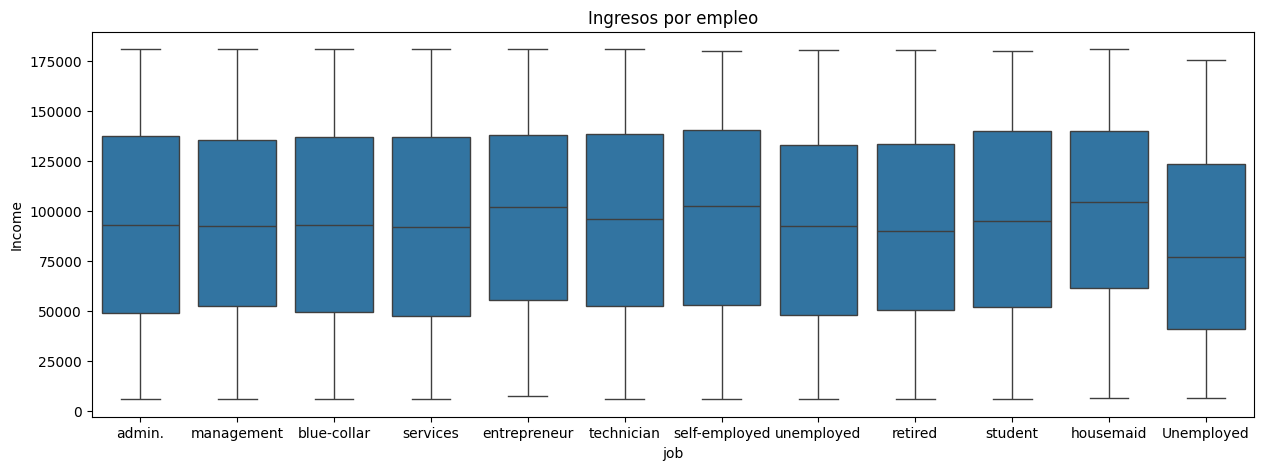

In [114]:
bank_data['Income_mean'] = general_mean

plt.figure(figsize=(15, 5))
sns.boxplot(data=bank_data, x='job', y='Income')
plt.title('Ingresos por empleo')
plt.show()



Vamos a verlo más específicamente.

In [115]:
# bank_data.groupby('marital')['Income'].head(2)
bank_data.groupby('education')['Income'].mean().reset_index().round(2)

,education,Income
0,No studies,95274.09
1,basic.4y,91721.84
2,basic.6y,91588.38
3,basic.9y,94575.23
4,high.school,94913.25
5,illiterate,92940.50
6,professional.course,94759.00
7,university.degree,92742.84


Filtrando nuestros datos por aquellos que cuentan sin educación, hemos llegado a la conclusión de que cuentan con la media de ingresos más superior.

In [116]:
no_studies = bank_data['education'] == "No studies"
noEducationPeople = bank_data[no_studies]

noEducationPeopleMean = noEducationPeople['Income']
general_mean = bank_data['Income'].mean()

print(f'La media general es de :  {general_mean.round(2)}€')
print(f'La media de los clientes sin estudios es:  {noEducationPeopleMean.mean().round(2)}€')


La media general es de :  93725.28€
La media de los clientes sin estudios es:  95274.09€


¿Cuáles son los tres trabajos mejor remunerados?

In [117]:
bank_data.groupby('job')['Income'].mean().sort_values(ascending=False).round(2).head(3)

job
housemaid        99474.71
self-employed    97892.68
entrepreneur     97395.71
Name: Income, dtype: float64

Agrupando ahora por situación amorosa llegamos a la conclusión de que los clientes que más han aguantado al teléfono han sido aquelllos que decidieron no responder a la misma. También comprobamos que el alcance de la campaña es de dos contactos de media esta última campaña para estos clientes.

In [118]:
bank_data.groupby('marital').mean(numeric_only = True).astype(int)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,Income,Kidhome,Teenhome,NumWebVisitsMonth,Income_mean
marital,,,,,,,,,,,,,,
DIVORCED,45,253,2,900,0,-1,93,-41,1,93512,1,1,16,93725
MARRIED,41,267,2,894,0,-1,93,-41,1,93970,1,0,16,93725
NO ANSWER,38,323,2,861,0,-1,92,-41,1,95626,0,0,16,93725
SINGLE,32,264,2,882,0,-1,93,-41,1,93385,1,1,16,93725


Teniendo en cuenta el gráfico anterior, vamos a sacar nuestro primer KPI, el capital total del banco

In [119]:
kpi_capitalTotal = bank_data['Income'].sum().round(2)
print(f'El capital total de la empresa es de {kpi_capitalTotal}€')

El capital total de la empresa es de 1318152393.0€


Nuestro siguiente KPI va a ser el total de clientes únicos que tenemos.

In [120]:
# Como bien comprobamos anteriormente, no contamos con ningún cliente repetido.
print(f'Número de clientes repetidos: {clientesDuplicados}')

kpi_numClientes = bank_data['ID'].count()
print(f'El total de clientes que tiene el banco es de: {kpi_numClientes} clientes únicos')
# 

Número de clientes repetidos: 0
El total de clientes que tiene el banco es de: 14064 clientes únicos


Para nuestro tercer KPI vamos a calcular la correlación entre el índice de confianza del consumidor y la tasa de interes de referencia a tres meses consumidor, para obtener la correlación de 'salud económica' de nuestros clientes.

Cómo información es importante saber lo siguiente:

- 0.0 a -0.3: Economía estable

- 0.3 a -0.7: Tensión económica moderada

- 0.7 a -1.0: Crisis económica severa 

In [ ]:

kpi_correlacionSalud = bank_data[['cons.conf.idx', 'euribor3m']].corr().iloc[0,1].round(2)

if kpi_correlacionSalud <= 0 and kpi_correlacionSalud >= -0.3:
    print(f"Economía estable: {kpi_correlacionSalud}")
elif kpi_correlacionSalud < -0.3 and kpi_correlacionSalud > -0.7:
    print(f"Tensión económica moderada: {kpi_correlacionSalud}")
    print(f"Crisis económica severa: {kpi_correlacionSalud}")
elif kpi_correlacionSalud <= -0.7:



Economía estable: -0.09


Por último vamos a sacar otro KPI para obtener la Volatilidad del Entorno MAcroeconómico (VEM) usando nuestra columna emp.var.rate.  
#                                               
Necesitaremos tener en cuenta:

# 
- CV < 20%: Mercado laboral muy estable
# 
- CV 20-50%: Volatilidad moderada
# 
- CV > 50%: Alta inestabilidad (crisis)

In [ ]:
volatilidad_empleo = bank_data['emp.var.rate'].std()
media_empleo = bank_data['emp.var.rate'].mean()
kpi_coefVariacion = ((volatilidad_empleo / abs(media_empleo)) * 100).round(2)

if kpi_coefVariacion <= 20:
    print(f"Mercado laboral muy estable: {kpi_coefVariacion}%")
elif kpi_coefVariacion >=20 and kpi_coefVariacion > 50:
    print(f"Volatilidad moderada: {kpi_coefVariacion}%")
elif kpi_coefVariacion >= 50:
    print(f"Alta inestabilidad (crisis): {kpi_coefVariacion}%")


Volatilidad moderada: 61.51%


Tras este análisis ahora tenemos nuestros KPI´s:

# KPI CapitalTotal -> 1318152393.0€
# KPI NumClientes -> 14064 clientes únicos
# KPI CorrelacionSalud -> Economía estable: -0.09
# KPI CoefVariacion -> Volatilidad moderada: 61.51%